# Original vs. Meta-Model Performance Distribution

This notebook generates figures comparing original models with meta-models (ensemble) for three different datasets:
1. Qwen3-30B vs MetaCH
2. GPT-5 vs AlphaMissense
3. GDD-ENS vs GPT-5 (GENIE dataset)

For each dataset, we show both Accuracy and F1 Score comparisons.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
from matplotlib import font_manager, rcParams
from matplotlib.lines import Line2D
import seaborn as sns
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
# Path to your font directory
font_dir = "/data1/morrisq/yuj13/share/fonts/liberation-fonts-ttf-2.1.5/"

# Register the font files with Matplotlib
font_manager.fontManager.addfont(font_dir + "LiberationSans-Regular.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Bold.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Italic.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-BoldItalic.ttf")

# Set Liberation Sans as the default font (Arial-compatible)
rcParams["font.family"] = "Liberation Sans"

## Load Data

In [10]:
# Load the three datasets
df1 = pd.read_csv('/data1/morrisq/yuj13/llm_genomics/mutation_meta_model_result/qwen3-30b_MetaCH_20260512_173044/10_fold_cv_detailed_results.csv')
df2 = pd.read_csv('/data1/morrisq/yuj13/llm_genomics/mutation_meta_model_result/gpt-5_AlphaMissense_10_fold_20251206_201157/10_fold_cv_detailed_results.csv')
df3 = pd.read_csv('/data1/morrisq/yuj13/llm_genomics/genie_meta_model_result/20251206_230739_gpt5_10fold/10_fold_cv_detailed_results.csv')

print(f"Dataset 1 (Qwen3-30B vs MetaCH): {len(df1)} folds")
print(f"Dataset 2 (GPT-5 vs AlphaMissense): {len(df2)} folds")
print(f"Dataset 3 (GDD-ENS vs GPT-5): {len(df3)} folds")

Dataset 1 (Qwen3-30B vs MetaCH): 10 folds
Dataset 2 (GPT-5 vs AlphaMissense): 10 folds
Dataset 3 (GDD-ENS vs GPT-5): 10 folds


## Helper Function to Draw Significance Brackets

In [11]:
def draw_significance_bracket(ax, x1, x2, y, p_value, height=0.02):
    """
    Draw a significance bracket between two positions
    
    Parameters:
    -----------
    ax : matplotlib axis
        Axis to draw on
    x1, x2 : float
        x positions for the bracket ends
    y : float
        y position for the bracket
    p_value : float
        p-value for determining significance marker
    height : float
        Height of the bracket ticks
    """
    # Determine significance marker
    if p_value < 0.001:
        sig_marker = '***'
    elif p_value < 0.01:
        sig_marker = '**'
    elif p_value < 0.05:
        sig_marker = '*'
    else:
        sig_marker = 'n.s.'
    
    # Draw the bracket
    ax.plot([x1, x1, x2, x2], [y, y+height, y+height, y], 
            linewidth=1.5, color='black')
    
    # Add text in the middle
    ax.text((x1+x2)/2, y+height, sig_marker, 
            ha='center', va='bottom', fontsize=14, fontweight='bold')
    
    return y + height + 0.007  # Return next y position

## Define Function to Create Box Plot Panel

In [12]:
def create_meta_model_boxplot_panel(ax, df, llm_model, task_model, meta_models, 
                                     rename_dict, title, n_label, metric_name='Accuracy',
                                     show_legend=False, show_dots=False, y_label=None,
                                     show_significance=True):
    """
    Create a box plot comparing original models with meta-models on a given axis
    
    Parameters:
    -----------
    ax : matplotlib axis
        Axis to plot on
    df : pandas.DataFrame
        DataFrame containing the model performance data
    llm_model : str
        LLM-based original model column name (e.g., 'gpt-4o_accuracy')
    task_model : str
        Task-specific original model column name (e.g., 'MetaCH_accuracy')
    meta_models : list
        List of meta-model column names
    rename_dict : dict
        Dictionary mapping column names to display names
    title : str
        Plot title
    n_label : str
        Label for sample size (e.g., "centers", "folds")
    metric_name : str
        Name of the metric being plotted (e.g., 'Accuracy', 'F1 Score')
    show_legend : bool
        Whether to show legend on this panel
    show_dots : bool
        Whether to overlay individual data points as dots on the boxplot
    y_label : str or None
        Custom y-axis label. If None, uses metric_name
    show_significance : bool
        Whether to show significance test brackets and labels (default: True)
    """
    original_models = [llm_model, task_model]
    all_models = original_models + meta_models
    
    # Prepare data for box plot
    data_for_box = []
    labels_for_box = []
    
    for col in all_models:
        data_for_box.append(df[col].values)
        labels_for_box.append(rename_dict[col])
    
    # Create box plot
    bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True, 
                     widths=0.6, showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='red', markersize=8),
                     medianprops=dict(color='black', linewidth=2.5))
    
    # Color original models differently from meta models
    # colors = ['#ff7f7f'] * len(original_models) + ['#7f7fff'] * len(meta_models)
    colors = ['#ffffff'] * len(original_models) + ['#ffffff'] * len(meta_models)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
        patch.set_linewidth(2)
    
    # Make whiskers and caps more visible
    for whisker in bp['whiskers']:
        whisker.set_linewidth(1.5)
    for cap in bp['caps']:
        cap.set_linewidth(1.5)
    
    # Overlay individual data points if requested
    if show_dots:
        for i, col in enumerate(all_models):
            x_pos = i + 1
            y_values = df[col].values
            # Add small random jitter to x positions for better visibility
            x_jitter = np.random.normal(0, 0.1, size=len(y_values))
            ax.scatter(x_pos + x_jitter, y_values, alpha=0.4, s=40, 
                      color='darkblue', edgecolors='darkblue', linewidth=0.5, zorder=3)
    
    # Calculate mean values for annotations
    mean_values = [df[col].mean() for col in all_models]
    
    # Add mean value labels above each box
    for i, (box, mean_val) in enumerate(zip(bp['boxes'], mean_values)):
        # Get the position of the box
        x_pos = i + 1
        # Get the upper quartile to position the text
        y_pos = box.get_path().vertices[:, 1].max()
        
        # Add mean value text
        if metric_name == "Accuracy":
            ax.text(x_pos, y_pos + 0.02, f'μ={mean_val*100:.1f}', 
                    ha='center', va='bottom', fontsize=26, fontweight='bold')
        else:
            ax.text(x_pos, y_pos + 0.02, f'μ={mean_val:.3f}', 
                    ha='center', va='bottom', fontsize=26, fontweight='bold')
    
    # Get y-limits for positioning significance brackets
    all_data = [df[col] for col in all_models]
    max_val = max([d.max() for d in all_data])
    
    # Starting y position for brackets (above the highest data point)
    current_y = max_val + 0.03
    
    # Perform Mann-Whitney U tests and draw significance brackets (if enabled)
    if show_significance:
        # LLM model is at position 1, task-specific model is at position 2
        # Meta models are at positions 3, 4, 5
        
        llm_pos = 1
        task_pos = 2
        meta_positions = [3, 4, 5]
        
        # Test LLM model vs each meta model
        for i, meta_col in enumerate(meta_models):
            meta_pos = meta_positions[i]
            _, p_value = stats.mannwhitneyu(df[llm_model], df[meta_col], alternative='two-sided')
            current_y = draw_significance_bracket(ax, llm_pos, meta_pos, current_y, p_value, height=0.001)
        
        # Test task-specific model vs each meta model
        for i, meta_col in enumerate(meta_models):
            meta_pos = meta_positions[i]
            _, p_value = stats.mannwhitneyu(df[task_model], df[meta_col], alternative='two-sided')
            current_y = draw_significance_bracket(ax, task_pos, meta_pos, current_y, p_value, height=0.001)
    
    # Add a horizontal line at the mean of original models for reference
    avg_original = np.mean([df[orig].mean() for orig in original_models])
    # ax.axhline(y=avg_original, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
    
    # Styling
    if y_label == None:
        if metric_name == "Accuracy":
            ax.set_ylabel(f"{metric_name} (%)", fontsize=28, fontweight='bold')
        else:
            ax.set_ylabel(metric_name, fontsize=28, fontweight='bold')
    else:
        ax.set_ylabel(f"{y_label}", fontsize=28, fontweight='bold')
    ax.set_title(title, fontsize=22, fontweight='bold', pad=10)
    ax.set_xticklabels(labels_for_box, rotation=0, ha='center', fontsize=20)
    ax.tick_params(axis='y', labelsize=28)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    # Set y-axis limits with extra padding for significance brackets
    min_val = min([d.min() for d in all_data])
    ax.set_ylim(min_val - 0.03, current_y + 0.005)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    if metric_name == "Accuracy":
        # Get current y-tick locations and labels
        yticks = ax.get_yticks()
        yticklabels = [item.get_text() for item in ax.get_yticklabels()]

        # Example: Add a suffix to each label
        new_yticklabels = [f"{int(float(label) * 100)}" for label in yticklabels]
        # Set the new y-tick labels
        ax.set_yticklabels(new_yticklabels)
    
    # Add percentage improvement annotations for meta models
    for i, col in enumerate(meta_models):
        improvement = ((df[col].mean() - df[task_model].mean()) / df[task_model].mean()) * 100
        box_idx = len(original_models) + i + 1
        
        # Add improvement percentage below the x-axis label
        ax.text(box_idx, -0.1, f'(+{improvement:.1f}%)', 
                ha='center', va='top', fontsize=20, 
                color='darkblue', fontweight='bold',
                transform=ax.get_xaxis_transform())
    
    # Add legend only to specified panel
    if show_legend:
        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D
        
        legend_elements = [
            # Patch(facecolor='#ff7f7f', edgecolor='black', label='Original Models'),
            # Patch(facecolor='#7f7fff', edgecolor='black', label='Meta Models (Ensemble)'),
            Line2D([0], [0], marker='D', color='w', markerfacecolor='red', 
                   markersize=8, label='Mean'),
            Line2D([0], [0], marker='_', color='black', linewidth=2, 
                   markersize=12, label='Median'),
            # Line2D([0], [0], color='red', linestyle='--', alpha=0.5, 
            #        label=f'Original Average: {avg_original:.4f}')
        ]
        
        # # Add dots to legend if they are shown
        # if show_dots:
        #     legend_elements.append(
        #         Line2D([0], [0], marker='o', color='w', markerfacecolor='darkblue', 
        #                markeredgecolor='black', markersize=8, label='Individual Points')
        #     )
        
        ax.legend(handles=legend_elements, loc='lower right', fontsize=20, framealpha=0.95)
    
    # Add sample size information
    n_samples = len(df)
    if show_significance:
        ax.text(0.02, 0.02, f'n = {n_samples} {n_label} * p<0.05, ** p<0.01, *** p<0.001 Mann-Whitney U test, EML: Emsemble Machine Learning', 
                transform=ax.transAxes, fontsize=10, style='italic', alpha=0.7)

    
    return avg_original

## Define Function to Print Statistics

In [13]:
def print_statistics(df, llm_model, task_model, meta_models, rename_dict, avg_original, dataset_name, metric_name='Accuracy'):
    """
    Print detailed statistical comparison
    """
    original_models = [llm_model, task_model]
    all_models = original_models + meta_models
    
    print(" " + "="*80)
    print(f"DETAILED STATISTICAL COMPARISON - {dataset_name} - {metric_name}")
    print("="*80)
    print(" Model Performance Summary:")
    print("-" * 80)
    print(f"{'Model':35s} {'Type':15s} {'Mean':>8s} {'Median':>8s} {'Std':>8s}")
    print("-" * 80)
    
    for col in all_models:
        name = rename_dict[col]
        type_ = 'Original' if col in original_models else 'Meta (Ensemble)'
        mean_val = df[col].mean()
        median_val = df[col].median()
        std_val = df[col].std()
        print(f"{name:35s} {type_:15s} {mean_val:8.4f} {median_val:8.4f} {std_val:8.4f}")
    
    print(" Quartile Information:")
    print("-" * 80)
    print(f"{'Model':35s} {'Q1':>8s} {'Q2':>8s} {'Q3':>8s} {'IQR':>8s}")
    print("-" * 80)
    
    for col in all_models:
        name = rename_dict[col]
        q1 = df[col].quantile(0.25)
        q2 = df[col].quantile(0.50)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        print(f"{name:35s} {q1:8.4f} {q2:8.4f} {q3:8.4f} {iqr:8.4f}")
    
    print(" Statistical Significance Tests (Mann-Whitney U tests):")
    print("-" * 80)
    print(f"{'Comparison':55s} {'U-statistic':>12s} {'p-value':>12s} {'Significance':^12s}")
    print("-" * 80)
    
    # LLM model vs meta models
    print(f" {rename_dict[llm_model]} vs Meta Models:")
    print("-" * 80)
    for meta in meta_models:
        u_stat, p_value = stats.mannwhitneyu(df[llm_model], df[meta], alternative='two-sided')
        sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "n.s."
        comparison = f"{rename_dict[llm_model]} vs {rename_dict[meta]}"
        print(f"{comparison:55s} {u_stat:12.2f} {p_value:12.6f}  {sig:^12s}")
    
    # Task-specific model vs meta models
    print(f" {rename_dict[task_model]} vs Meta Models:")
    print("-" * 80)
    for meta in meta_models:
        u_stat, p_value = stats.mannwhitneyu(df[task_model], df[meta], alternative='two-sided')
        sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "n.s."
        comparison = f"{rename_dict[task_model]} vs {rename_dict[meta]}"
        print(f"{comparison:55s} {u_stat:12.2f} {p_value:12.6f}  {sig:^12s}")
    
    print(" Improvement over Original Models Average:")
    print("-" * 80)
    for meta in meta_models:
        improvement = ((df[meta].mean() - avg_original) / avg_original) * 100
        print(f"{rename_dict[meta]:35s}: +{improvement:.2f}%")
    
    print("="*80)

## Create Combined Figure: Accuracy (Three Panels)

/tmp/ipykernel_3410551/3651204417.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True,
/tmp/ipykernel_3410551/3651204417.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_yticklabels)
/tmp/ipykernel_3410551/3651204417.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True,
/tmp/ipykernel_3410551/3651204417.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_yticklabels)
/tmp/ipykernel_3

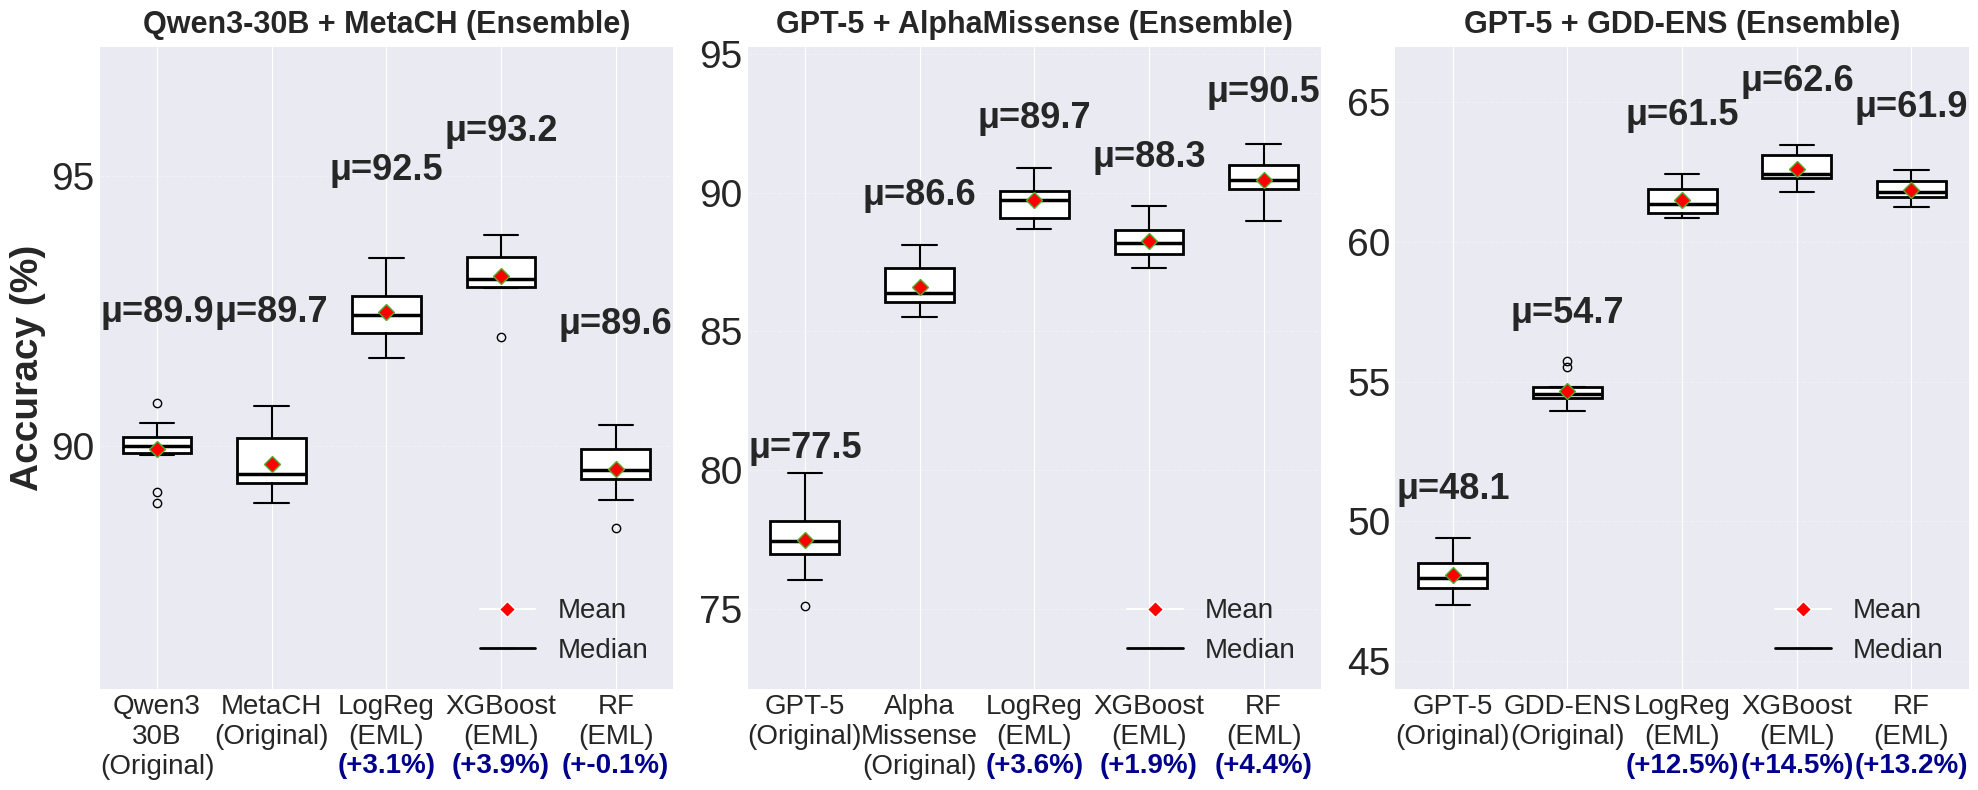

In [14]:
# Define model groups for all three datasets - ACCURACY
# Dataset 1: Qwen3-30B (LLM) vs MetaCH (task-specific)
llm_model_1_acc = 'qwen3-30b_accuracy'
task_model_1_acc = 'MetaCH_accuracy'
meta_models_1_acc = ['LogReg_accuracy', 'XGBoost_accuracy', 'RandomForest_accuracy']
rename_dict_1_acc = {
    'qwen3-30b_accuracy': 'Qwen3\n30B\n(Original)',
    'MetaCH_accuracy': 'MetaCH\n(Original)',
    'LogReg_accuracy': 'LogReg\n(EML)',
    'XGBoost_accuracy': 'XGBoost\n(EML)',
    'RandomForest_accuracy': 'RF\n(EML)'
}

# Dataset 2: GPT-5 (LLM) vs AlphaMissense (task-specific)
llm_model_2_acc = 'gpt-5_accuracy'
task_model_2_acc = 'AlphaMissense_accuracy'
meta_models_2_acc = ['LogReg_accuracy', 'XGBoost_accuracy', 'RandomForest_accuracy']
rename_dict_2_acc = {
    'gpt-5_accuracy': 'GPT-5\n(Original)',
    'AlphaMissense_accuracy': 'Alpha\nMissense\n(Original)',
    'LogReg_accuracy': 'LogReg\n(EML)',
    'XGBoost_accuracy': 'XGBoost\n(EML)',
    'RandomForest_accuracy': 'RF\n(EML)'
}

# Dataset 3: GPT-5 (LLM) vs GDD-ENS (task-specific)
llm_model_3_acc = 'gpt_5_accuracy'
task_model_3_acc = 'GDD_accuracy'
meta_models_3_acc = ['LogReg_accuracy', 'XGBoost_accuracy', 'RandomForest_accuracy']
rename_dict_3_acc = {
    'gpt_5_accuracy': 'GPT-5\n(Original)',
    'GDD_accuracy': 'GDD-ENS\n(Original)',
    'LogReg_accuracy': 'LogReg\n(EML)',
    'XGBoost_accuracy': 'XGBoost\n(EML)',
    'RandomForest_accuracy': 'RF\n(EML)'
}

# Create figure with three panels in one row for ACCURACY
fig_acc, axes_acc = plt.subplots(1, 3, figsize=(20, 8))

# Create each panel
avg_orig_1_acc = create_meta_model_boxplot_panel(
    axes_acc[0], df1, llm_model_1_acc, task_model_1_acc, meta_models_1_acc, rename_dict_1_acc,
    'Qwen3-30B + MetaCH (Ensemble)', 'folds', metric_name='Accuracy', show_legend=True, show_significance=False
)

avg_orig_2_acc = create_meta_model_boxplot_panel(
    axes_acc[1], df2, llm_model_2_acc, task_model_2_acc, meta_models_2_acc, rename_dict_2_acc,
    'GPT-5 + AlphaMissense (Ensemble)', 'folds', metric_name='Accuracy', show_legend=True, y_label="", show_significance=False
)

avg_orig_3_acc = create_meta_model_boxplot_panel(
    axes_acc[2], df3, llm_model_3_acc, task_model_3_acc, meta_models_3_acc, rename_dict_3_acc,
    'GPT-5 + GDD-ENS (Ensemble)', 'folds', metric_name='Accuracy', show_legend=True, y_label="", show_significance=False
)

# # Add overall title
# fig_acc.suptitle('Original vs. Ensemble Performance Distribution - Accuracy', 
#                  fontsize=20, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

## Create Combined Figure: Accuracy with Overlaying Dots (Three Panels)

/tmp/ipykernel_3410551/3651204417.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True,
/tmp/ipykernel_3410551/3651204417.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_yticklabels)
/tmp/ipykernel_3410551/3651204417.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True,
/tmp/ipykernel_3410551/3651204417.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_yticklabels)
/tmp/ipykernel_3

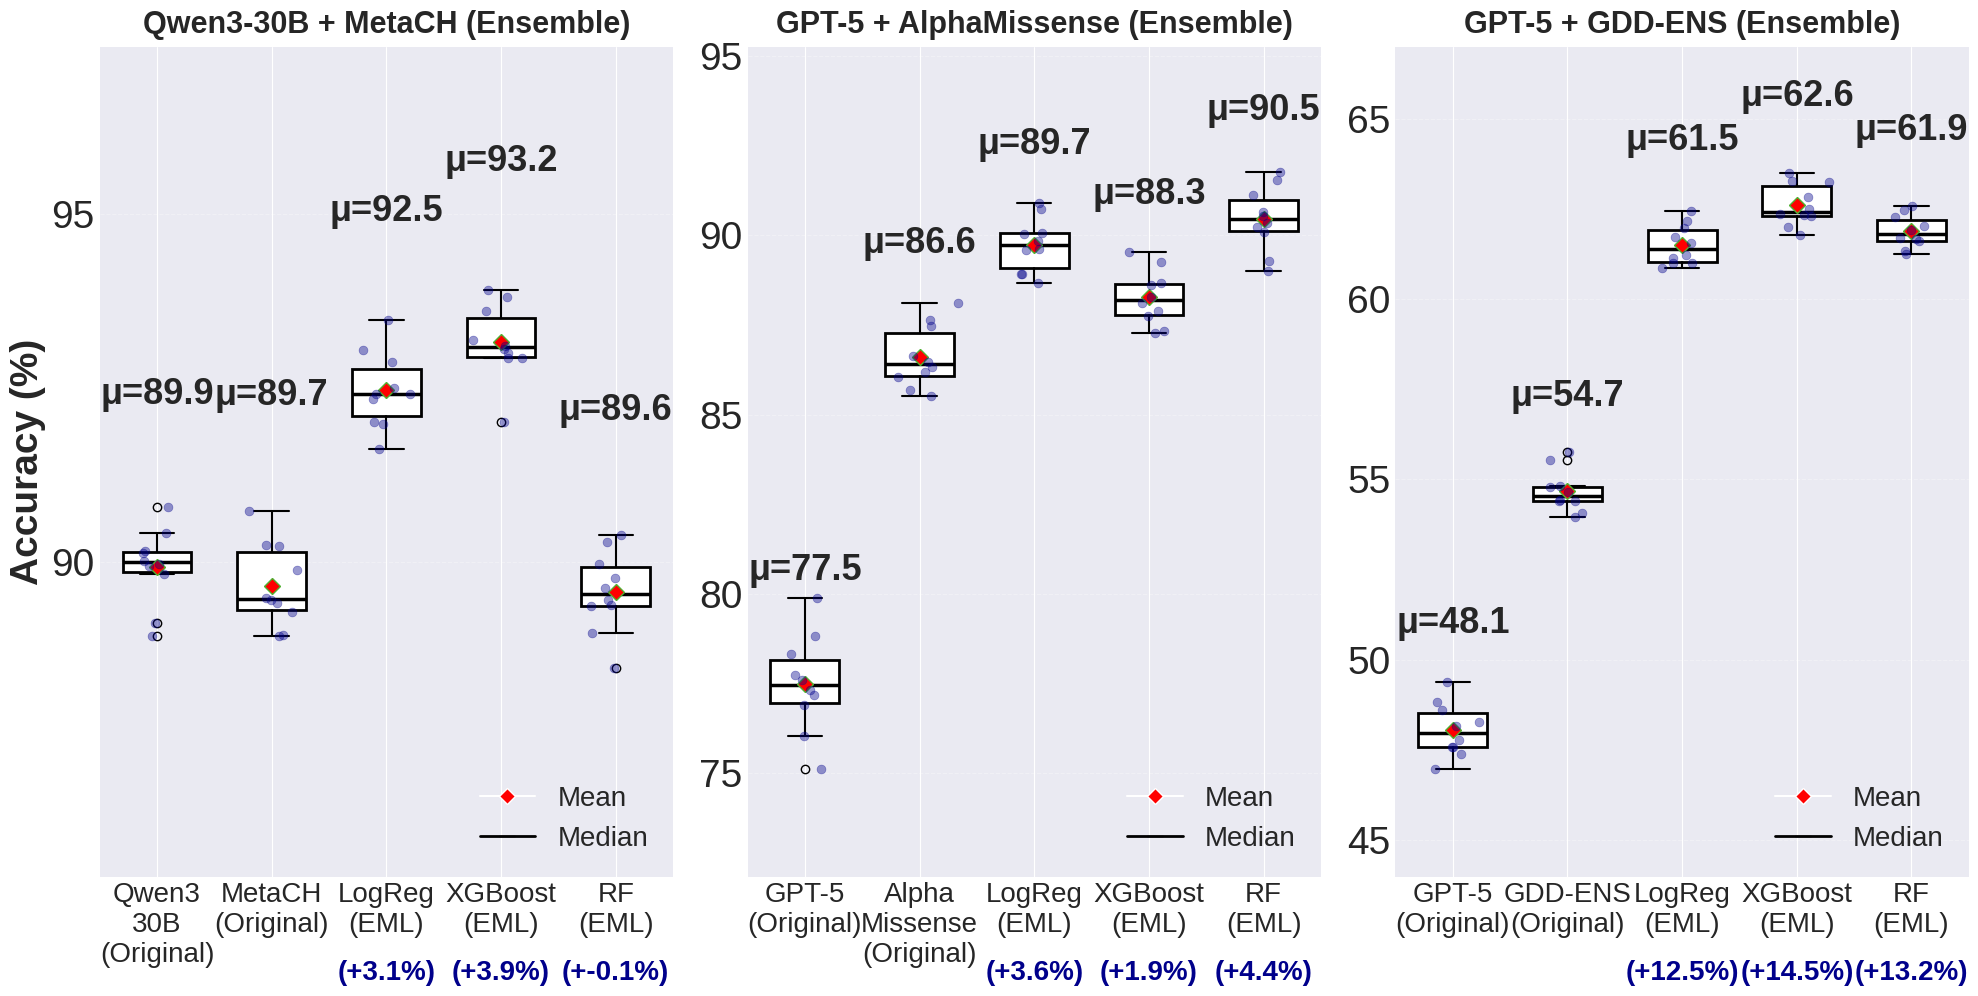

In [15]:
# Create figure with three panels in one row for ACCURACY WITH DOTS
fig_acc_dots, axes_acc_dots = plt.subplots(1, 3, figsize=(20, 10))

# Create each panel with show_dots=True
avg_orig_1_acc_dots = create_meta_model_boxplot_panel(
    axes_acc_dots[0], df1, llm_model_1_acc, task_model_1_acc, meta_models_1_acc, rename_dict_1_acc,
    'Qwen3-30B + MetaCH (Ensemble)', 'folds', metric_name='Accuracy', show_legend=True, show_dots=True, show_significance=False
)

avg_orig_2_acc_dots = create_meta_model_boxplot_panel(
    axes_acc_dots[1], df2, llm_model_2_acc, task_model_2_acc, meta_models_2_acc, rename_dict_2_acc,
    'GPT-5 + AlphaMissense (Ensemble)', 'folds', metric_name='Accuracy', show_legend=True, show_dots=True, y_label='', show_significance=False
)

avg_orig_3_acc_dots = create_meta_model_boxplot_panel(
    axes_acc_dots[2], df3, llm_model_3_acc, task_model_3_acc, meta_models_3_acc, rename_dict_3_acc,
    'GPT-5 + GDD-ENS (Ensemble)', 'folds', metric_name='Accuracy', show_legend=True, show_dots=True, y_label='', show_significance=False
)

# # Add overall title
# fig_acc_dots.suptitle('Original vs. Ensemble Performance Distribution - Accuracy', 
#                       fontsize=20, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig("plots/meta_model_combined_accuracy.png")
plt.savefig("plots/meta_model_combined_accuracy.pdf")
plt.show()

## Create Combined Figure: F1 Score (Three Panels)

/tmp/ipykernel_3410551/3651204417.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True,
/tmp/ipykernel_3410551/3651204417.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True,
/tmp/ipykernel_3410551/3651204417.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True,


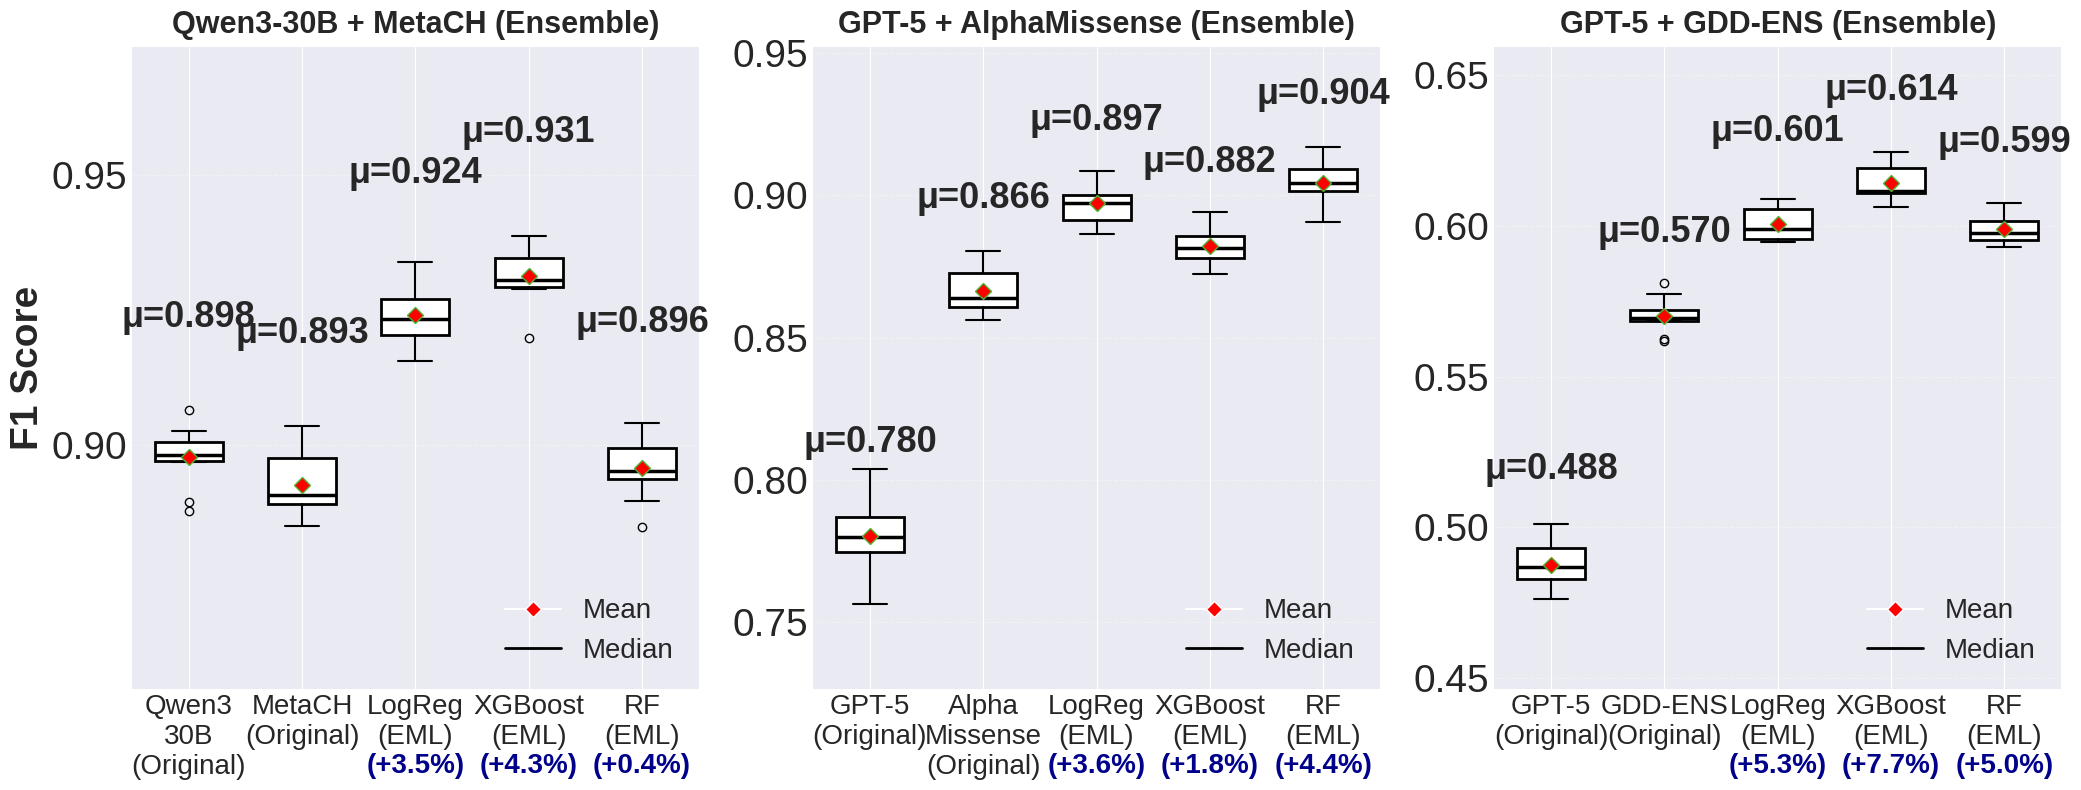

In [16]:
# Define model groups for all three datasets - F1 SCORE
# Dataset 1: Qwen3-30B (LLM) vs MetaCH (task-specific)
llm_model_1_f1 = 'qwen3-30b_f1'
task_model_1_f1 = 'MetaCH_f1'
meta_models_1_f1 = ['LogReg_f1', 'XGBoost_f1', 'RandomForest_f1']
rename_dict_1_f1 = {
    'qwen3-30b_f1': 'Qwen3\n30B\n(Original)',
    'MetaCH_f1': 'MetaCH\n(Original)',
    'LogReg_f1': 'LogReg\n(EML)',
    'XGBoost_f1': 'XGBoost\n(EML)',
    'RandomForest_f1': 'RF\n(EML)'
}

# Dataset 2: GPT-5 (LLM) vs AlphaMissense (task-specific)
llm_model_2_f1 = 'gpt-5_f1'
task_model_2_f1 = 'AlphaMissense_f1'
meta_models_2_f1 = ['LogReg_f1', 'XGBoost_f1', 'RandomForest_f1']
rename_dict_2_f1 = {
    'gpt-5_f1': 'GPT-5\n(Original)',
    'AlphaMissense_f1': 'Alpha\nMissense\n(Original)',
    'LogReg_f1': 'LogReg\n(EML)',
    'XGBoost_f1': 'XGBoost\n(EML)',
    'RandomForest_f1': 'RF\n(EML)'
}

# Dataset 3: GPT-5 (LLM) vs GDD-ENS (task-specific)
llm_model_3_f1 = 'gpt_5_f1'
task_model_3_f1 = 'GDD_f1'
meta_models_3_f1 = ['LogReg_f1', 'XGBoost_f1', 'RandomForest_f1']
rename_dict_3_f1 = {
    'gpt_5_f1': 'GPT-5\n(Original)',
    'GDD_f1': 'GDD-ENS\n(Original)',
    'LogReg_f1': 'LogReg\n(EML)',
    'XGBoost_f1': 'XGBoost\n(EML)',
    'RandomForest_f1': 'RF\n(EML)'
}

# Create figure with three panels in one row for F1 SCORE
fig_f1, axes_f1 = plt.subplots(1, 3, figsize=(21, 8))

# Create each panel
avg_orig_1_f1 = create_meta_model_boxplot_panel(
    axes_f1[0], df1, llm_model_1_f1, task_model_1_f1, meta_models_1_f1, rename_dict_1_f1,
    'Qwen3-30B + MetaCH (Ensemble)', 'folds', metric_name='F1 Score', show_legend=True, show_significance=False
)

avg_orig_2_f1 = create_meta_model_boxplot_panel(
    axes_f1[1], df2, llm_model_2_f1, task_model_2_f1, meta_models_2_f1, rename_dict_2_f1,
    'GPT-5 + AlphaMissense (Ensemble)', 'folds', metric_name='F1 Score', show_legend=True, y_label='', show_significance=False
)

avg_orig_3_f1 = create_meta_model_boxplot_panel(
    axes_f1[2], df3, llm_model_3_f1, task_model_3_f1, meta_models_3_f1, rename_dict_3_f1,
    'GPT-5 + GDD-ENS (Ensemble)', 'folds', metric_name='F1 Score', show_legend=True, y_label='', show_significance=False
)

# # Add overall title
# fig_f1.suptitle('Original vs. Ensemble Model Performance Distribution - F1 Score', 
#                 fontsize=20, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

## Create Combined Figure: F1 Score with Overlaying Dots (Three Panels)

/tmp/ipykernel_3410551/3651204417.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True,
/tmp/ipykernel_3410551/3651204417.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True,
/tmp/ipykernel_3410551/3651204417.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True,


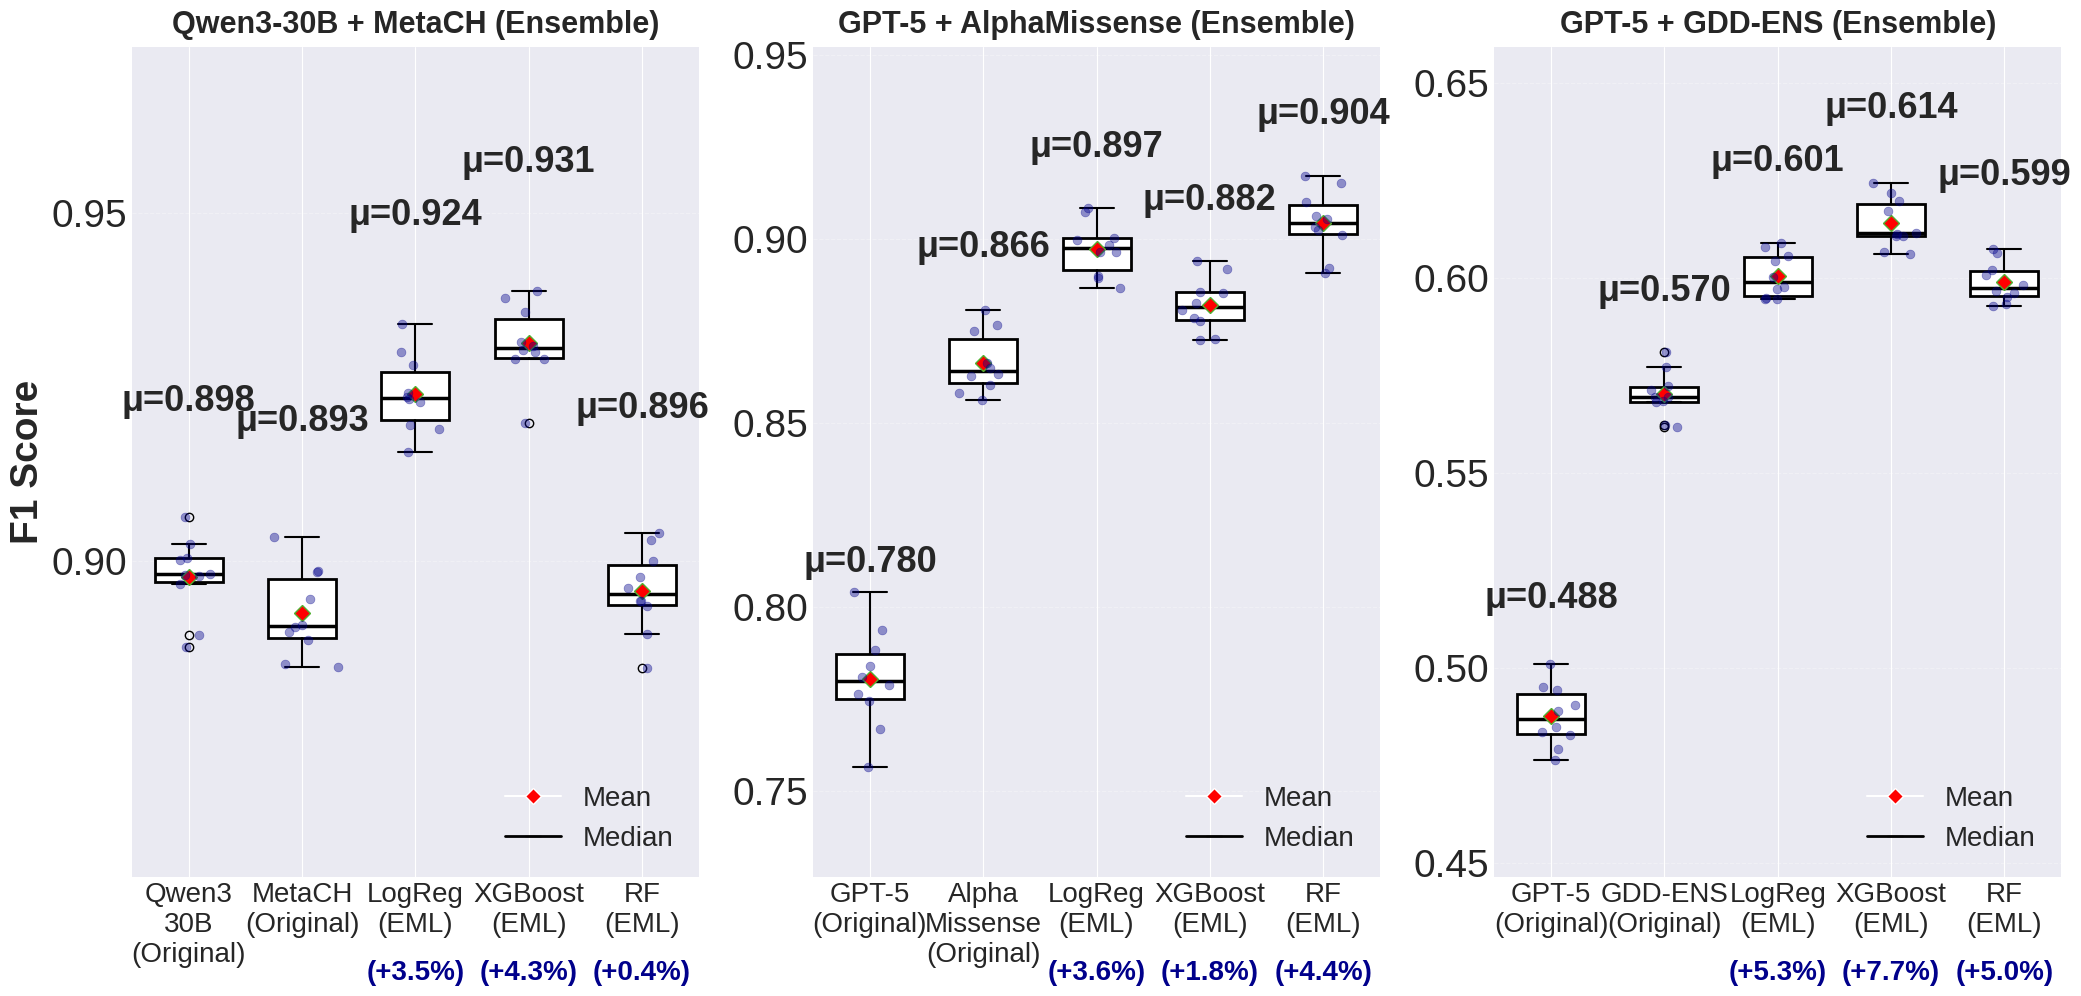

In [17]:
# Create figure with three panels in one row for F1 SCORE WITH DOTS
fig_f1_dots, axes_f1_dots = plt.subplots(1, 3, figsize=(21, 10))

# Create each panel with show_dots=True
avg_orig_1_f1_dots = create_meta_model_boxplot_panel(
    axes_f1_dots[0], df1, llm_model_1_f1, task_model_1_f1, meta_models_1_f1, rename_dict_1_f1,
    'Qwen3-30B + MetaCH (Ensemble)', 'folds', metric_name='F1 Score', show_legend=True, show_dots=True, show_significance=False
)

avg_orig_2_f1_dots = create_meta_model_boxplot_panel(
    axes_f1_dots[1], df2, llm_model_2_f1, task_model_2_f1, meta_models_2_f1, rename_dict_2_f1,
    'GPT-5 + AlphaMissense (Ensemble)', 'folds', metric_name='F1 Score', show_legend=True, show_dots=True, y_label='', show_significance=False
)

avg_orig_3_f1_dots = create_meta_model_boxplot_panel(
    axes_f1_dots[2], df3, llm_model_3_f1, task_model_3_f1, meta_models_3_f1, rename_dict_3_f1,
    'GPT-5 + GDD-ENS (Ensemble)', 'folds', metric_name='F1 Score', show_legend=True, show_dots=True, y_label='', show_significance=False
)

# # Add overall title
# fig_f1_dots.suptitle('Original vs. Ensemble Model Performance Distribution - F1 Score', 
#                      fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig("plots/meta_model_combined_f1.png")
plt.savefig("plots/meta_model_combined_f1.pdf")
plt.show()

## Print Statistics for All Datasets - Accuracy

In [ ]:
# Print statistics for all three datasets - ACCURACY
print_statistics(df1, llm_model_1_acc, task_model_1_acc, meta_models_1_acc, rename_dict_1_acc, 
                avg_orig_1_acc, "Qwen3-30B + MetaCH", "Accuracy")
print_statistics(df2, llm_model_2_acc, task_model_2_acc, meta_models_2_acc, rename_dict_2_acc, 
                avg_orig_2_acc, "GPT-5 + AlphaMissense", "Accuracy")
print_statistics(df3, llm_model_3_acc, task_model_3_acc, meta_models_3_acc, rename_dict_3_acc, 
                avg_orig_3_acc, "GPT-5 + GDD-ENS (GENIE)", "Accuracy")

## Print Statistics for All Datasets - F1 Score

In [ ]:
# Print statistics for all three datasets - F1 SCORE
print_statistics(df1, llm_model_1_f1, task_model_1_f1, meta_models_1_f1, rename_dict_1_f1, 
                avg_orig_1_f1, "Qwen3-30B + MetaCH", "F1 Score")
print_statistics(df2, llm_model_2_f1, task_model_2_f1, meta_models_2_f1, rename_dict_2_f1, 
                avg_orig_2_f1, "GPT-5 + AlphaMissense", "F1 Score")
print_statistics(df3, llm_model_3_f1, task_model_3_f1, meta_models_3_f1, rename_dict_3_f1, 
                avg_orig_3_f1, "GPT-5 + GDD-ENS (GENIE)", "F1 Score")

## Save Figures (Optional)

In [17]:
# Save the combined figures
fig_acc.savefig('plots/meta_model_all_accuracy.pdf', dpi=300, bbox_inches='tight')
fig_f1.savefig('plots/meta_model_all_f1.pdf', dpi=300, bbox_inches='tight')
print(" Figures saved successfully!")
print("- Accuracy: plot_meta_model_comparison_accuracy.pdf")
print("- F1 Score: plot_meta_model_comparison_f1.pdf")

 Figures saved successfully!
- Accuracy: plot_meta_model_comparison_accuracy.pdf
- F1 Score: plot_meta_model_comparison_f1.pdf


In [18]:
# Save the combined figures
fig_acc.savefig('plots/meta_model_all_accuracy.pdf', dpi=300, bbox_inches='tight')
fig_f1.savefig('plots/meta_model_all_f1.pdf', dpi=300, bbox_inches='tight')
print(" Figures saved successfully!")
print("- Accuracy: plot_meta_model_comparison_accuracy.pdf")
print("- F1 Score: plot_meta_model_comparison_f1.pdf")

 Figures saved successfully!
- Accuracy: plot_meta_model_comparison_accuracy.pdf
- F1 Score: plot_meta_model_comparison_f1.pdf


## GPT-5 + Retrained GDD-ENS Ensemble Performance by Center (COLU vs DFCI)

In [40]:
# Load and process 10-fold CV test data for GPT-5 + Retrained GDD-ENS
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Configuration: set to True to include original GDD-ENS comparison
INCLUDE_ORIGINAL_GDD = True  # Set to False to only show retrained GDD-ENS

# Load the cancer type mapping file (dot notation -> human-readable)
mapping_df = pd.read_table("/data1/morrisq/yuj13/llm_genomics/GDD_ENS/data/tumor_type_final.txt")
mapping_df_first = mapping_df[['CANCER_TYPE', 'Cancer_Type']].drop_duplicates(subset='Cancer_Type', keep='first')
dot_to_readable = dict(zip(mapping_df_first['Cancer_Type'], mapping_df_first['CANCER_TYPE']))
print(f"Loaded {len(dot_to_readable)} cancer type mappings")

# # option 1: without_any_filtered_out commands
# gpt_retrained_gddens_ensemble_path = '/data1/morrisq/yuj13/llm_genomics/genie_meta_model_result/without_any_filtered_out_gdd_gpt5_10fold_20260409_152836'
# gpt_original_gddens_ensemble_path = '/data1/morrisq/yuj13/llm_genomics/genie_meta_model_result/without_any_filtered_out_gdd_gpt5_match_10fold_20260409_150416'
# retrained_gddens_path = '/data1/morrisq/yuj13/llm_genomics/genie_meta_model_retrained_analysis_output/without_any_filtered_out/GDD-ENS-retrained'
# original_gddens_path = '/data1/morrisq/yuj13/llm_genomics/genie_meta_model_retrained_analysis_output/without_any_filtered_out/GDD-ENS-original-retrained-match'

# option 2: with_20percent_filtered_out commands
gpt_retrained_gddens_ensemble_path = '/data1/morrisq/yuj13/llm_genomics/genie_meta_model_result/with_20percent_filtered_out_gdd_gpt5_10fold_20260409_162651'
gpt_original_gddens_ensemble_path = '/data1/morrisq/yuj13/llm_genomics/genie_meta_model_result/with_20percent_filtered_out_gdd_gpt5_match_10fold_20260409_160218'
retrained_gddens_path = '/data1/morrisq/yuj13/llm_genomics/genie_meta_model_retrained_analysis_output/with_20percent_filtered_out/GDD-ENS-retrained'
original_gddens_path = '/data1/morrisq/yuj13/llm_genomics/genie_meta_model_retrained_analysis_output/with_20percent_filtered_out/GDD-ENS-original-retrained-match'

# # option 3: with_all_filtered_out commands
# gpt_retrained_gddens_ensemble_path = '/data1/morrisq/yuj13/llm_genomics/genie_meta_model_result/with_all_filtered_out_gdd_gpt5_10fold_20260409_152836'
# gpt_original_gddens_ensemble_path = '/data1/morrisq/yuj13/llm_genomics/genie_meta_model_result/with_all_filtered_out_gdd_gpt5_match_10fold_20260409_150416'
# retrained_gddens_path = '/data1/morrisq/yuj13/llm_genomics/genie_meta_model_retrained_analysis_output/with_all_filtered_out/GDD-ENS-retrained'
# original_gddens_path = '/data1/morrisq/yuj13/llm_genomics/genie_meta_model_retrained_analysis_output/with_all_filtered_out/GDD-ENS-original-retrained-match'


# Load the test data for GPT-5 + retrained GDD-ENS ensemble
df_retrained = pd.read_csv(f'{gpt_retrained_gddens_ensemble_path}/test_data/10_fold_cv_LogReg_test_data.csv')

# Extract center from SAMPLE_ID
df_retrained['center'] = df_retrained['SAMPLE_ID'].apply(lambda x: 'COLU' if 'COLU' in x else 'DFCI')

# Calculate metrics per center per fold
def calculate_fold_metrics(df, center):
    """Calculate metrics for each fold for a specific center"""
    center_df = df[df['center'] == center]
    metrics_by_fold = []
    
    for fold in center_df['fold'].unique():
        fold_df = center_df[center_df['fold'] == fold]
        y_true = fold_df['ground_truth']
        y_pred = fold_df['ensemble_prediction']
        
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='weighted')
        precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        
        metrics_by_fold.append({
            'fold': fold,
            'accuracy': acc,
            'f1': f1,
            'precision': precision,
            'recall': recall
        })
    
    return pd.DataFrame(metrics_by_fold)

# Calculate metrics for COLU and DFCI
metrics_colu_retrained = calculate_fold_metrics(df_retrained, 'COLU')
metrics_dfci_retrained = calculate_fold_metrics(df_retrained, 'DFCI')

print("GPT-5 + Retrained GDD-ENS Metrics:")
print(f"COLU - Accuracy: {metrics_colu_retrained['accuracy'].mean():.4f} ± {metrics_colu_retrained['accuracy'].std():.4f}")
print(f"COLU - F1: {metrics_colu_retrained['f1'].mean():.4f} ± {metrics_colu_retrained['f1'].std():.4f}")
print(f"DFCI - Accuracy: {metrics_dfci_retrained['accuracy'].mean():.4f} ± {metrics_dfci_retrained['accuracy'].std():.4f}")
print(f"DFCI - F1: {metrics_dfci_retrained['f1'].mean():.4f} ± {metrics_dfci_retrained['f1'].std():.4f}")

# Load standalone GDD-ENS-retrained metrics
df_gdd_retrained_colu = pd.read_csv(f'{retrained_gddens_path}/ensemble_allprobs_colu_anno.csv')
df_gdd_retrained_dfci = pd.read_csv(f'{retrained_gddens_path}/ensemble_allprobs_dfci_anno.csv')

# Calculate GDD-ENS retrained standalone metrics
gdd_retrained_acc_colu = accuracy_score(df_gdd_retrained_colu['target_name'], df_gdd_retrained_colu['inference_name'])
gdd_retrained_f1_colu = f1_score(df_gdd_retrained_colu['target_name'], df_gdd_retrained_colu['inference_name'], average='weighted')
gdd_retrained_acc_dfci = accuracy_score(df_gdd_retrained_dfci['target_name'], df_gdd_retrained_dfci['inference_name'])
gdd_retrained_f1_dfci = f1_score(df_gdd_retrained_dfci['target_name'], df_gdd_retrained_dfci['inference_name'], average='weighted')

print(f" GDD-ENS Retrained (standalone):")
print(f"COLU - Accuracy: {gdd_retrained_acc_colu:.4f}, F1: {gdd_retrained_f1_colu:.4f}")
print(f"DFCI - Accuracy: {gdd_retrained_acc_dfci:.4f}, F1: {gdd_retrained_f1_dfci:.4f}")

if INCLUDE_ORIGINAL_GDD:
    # Load the test data for GPT-5 + original GDD-ENS match ensemble
    df_original = pd.read_csv(f'{gpt_original_gddens_ensemble_path}/test_data/10_fold_cv_LogReg_test_data.csv')
    df_original['center'] = df_original['SAMPLE_ID'].apply(lambda x: 'COLU' if 'COLU' in x else 'DFCI')
    
    # Calculate metrics for original GDD-ENS ensemble
    metrics_colu_original = calculate_fold_metrics(df_original, 'COLU')
    metrics_dfci_original = calculate_fold_metrics(df_original, 'DFCI')
    
    print(f" GPT-5 + Original GDD-ENS Metrics:")
    print(f"COLU - Accuracy: {metrics_colu_original['accuracy'].mean():.4f} ± {metrics_colu_original['accuracy'].std():.4f}")
    print(f"COLU - F1: {metrics_colu_original['f1'].mean():.4f} ± {metrics_colu_original['f1'].std():.4f}")
    print(f"DFCI - Accuracy: {metrics_dfci_original['accuracy'].mean():.4f} ± {metrics_dfci_original['accuracy'].std():.4f}")
    print(f"DFCI - F1: {metrics_dfci_original['f1'].mean():.4f} ± {metrics_dfci_original['f1'].std():.4f}")
    
    # Load standalone GDD-ENS-original metrics (matched samples)
    df_gdd_original_colu = pd.read_csv(f'{original_gddens_path}/filtered_colu_match.csv')
    df_gdd_original_dfci = pd.read_csv(f'{original_gddens_path}/filtered_dfci_match.csv')
    
    # Use the proper mapping from tumor_type_final.txt to convert Pred1 (dot notation) to human-readable format
    df_gdd_original_colu['pred_mapped'] = df_gdd_original_colu['Pred1'].map(dot_to_readable)
    df_gdd_original_dfci['pred_mapped'] = df_gdd_original_dfci['Pred1'].map(dot_to_readable)
    
    # Check for unmapped predictions and handle them
    unmapped_colu = df_gdd_original_colu['pred_mapped'].isna().sum()
    unmapped_dfci = df_gdd_original_dfci['pred_mapped'].isna().sum()
    if unmapped_colu > 0 or unmapped_dfci > 0:
        print(f" Warning: {unmapped_colu} COLU and {unmapped_dfci} DFCI predictions could not be mapped")
        # For unmapped, keep original (will likely be wrong but better than NaN)
        df_gdd_original_colu['pred_mapped'] = df_gdd_original_colu['pred_mapped'].fillna(df_gdd_original_colu['Pred1'])
        df_gdd_original_dfci['pred_mapped'] = df_gdd_original_dfci['pred_mapped'].fillna(df_gdd_original_dfci['Pred1'])
    
    gdd_original_acc_colu = accuracy_score(df_gdd_original_colu['Cancer_Type'], df_gdd_original_colu['pred_mapped'])
    gdd_original_f1_colu = f1_score(df_gdd_original_colu['Cancer_Type'], df_gdd_original_colu['pred_mapped'], average='weighted')
    gdd_original_acc_dfci = accuracy_score(df_gdd_original_dfci['Cancer_Type'], df_gdd_original_dfci['pred_mapped'])
    gdd_original_f1_dfci = f1_score(df_gdd_original_dfci['Cancer_Type'], df_gdd_original_dfci['pred_mapped'], average='weighted')
    
    print(f" GDD-ENS Original (standalone, with proper mapping):")
    print(f"COLU - Accuracy: {gdd_original_acc_colu:.4f}, F1: {gdd_original_f1_colu:.4f}")
    print(f"DFCI - Accuracy: {gdd_original_acc_dfci:.4f}, F1: {gdd_original_f1_dfci:.4f}")

Loaded 38 cancer type mappings
GPT-5 + Retrained GDD-ENS Metrics:
COLU - Accuracy: 0.5906 ± 0.0570
COLU - F1: 0.5640 ± 0.0507
DFCI - Accuracy: 0.6532 ± 0.0185
DFCI - F1: 0.6333 ± 0.0211
 GDD-ENS Retrained (standalone):
COLU - Accuracy: 0.5895, F1: 0.5587
DFCI - Accuracy: 0.6501, F1: 0.6403
 GPT-5 + Original GDD-ENS Metrics:
COLU - Accuracy: 0.4856 ± 0.0535
COLU - F1: 0.4930 ± 0.0464
DFCI - Accuracy: 0.6015 ± 0.0147
DFCI - F1: 0.5738 ± 0.0180
 GDD-ENS Original (standalone, with proper mapping):
COLU - Accuracy: 0.3818, F1: 0.4165
DFCI - Accuracy: 0.5730, F1: 0.5689


/tmp/ipykernel_344736/1459432862.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(y * 100)}' for y in yticks])


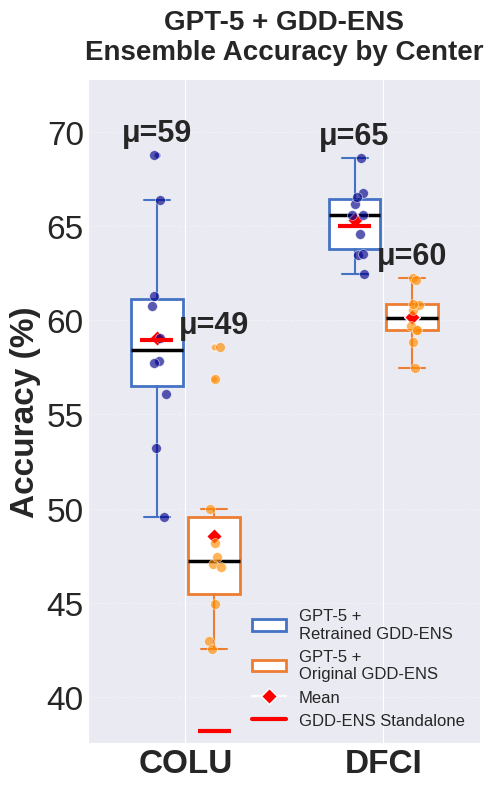

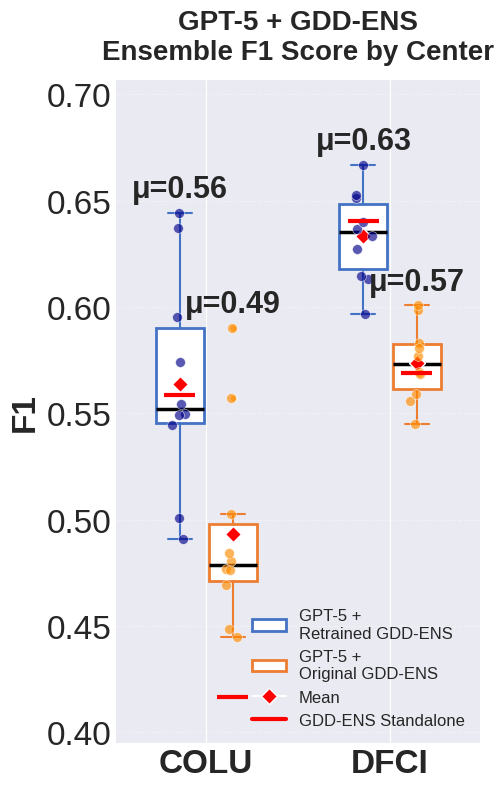


Figures saved:
- plots/gpt5_gdd_center_comparison_accuracy.png/pdf
- plots/gpt5_gdd_center_comparison_f1.png/pdf


In [47]:
# Create the visualization with vertical boxplots by center
# Color scheme consistent with existing notebook (dark blue for dots, white boxes)

def create_center_comparison_plot(
    metrics_list,
    center_names,
    model_names,
    standalone_metrics,
    metric_type='accuracy',
    figsize=(10, 8),
    title=None
):
    """
    Create boxplot comparing models across centers with standalone metric markers.
    """

    fig, ax = plt.subplots(figsize=figsize)

    n_centers = len(center_names)
    n_models = len(model_names)

    # Colors
    model_colors = ['#4472C4', '#ED7D31']  # Blue, Orange
    dot_colors = ['darkblue', 'darkorange']

    # ===== spacing controls =====
    box_width = 0.38       # actual box width
    intra_gap = 0.04       # gap between boxes within the same center
    center_gap = 0.65      # gap between center groups
    jitter_sd = 0.035      # horizontal jitter for dots
    # ===========================

    all_data = []
    all_positions = []
    all_colors = []
    all_dot_colors = []
    tick_positions = []

    # Prepare positions
    for center_idx, center in enumerate(center_names):
        group_start = center_idx * (n_models * box_width + (n_models - 1) * intra_gap + center_gap)

        center_positions = []
        for model_idx in range(n_models):
            pos = group_start + model_idx * (box_width + intra_gap)
            center_positions.append(pos)

            all_positions.append(pos)
            all_data.append(metrics_list[center_idx][model_idx][metric_type].values)
            all_colors.append(model_colors[model_idx])
            all_dot_colors.append(dot_colors[model_idx])

        tick_positions.append(np.mean(center_positions))

    # Create boxplots
    bp = ax.boxplot(
        all_data,
        positions=all_positions,
        widths=box_width,
        patch_artist=True,
        showmeans=True,
        meanprops=dict(marker='D', markerfacecolor='red', markeredgecolor='white', markersize=8),
        medianprops=dict(color='black', linewidth=2.5)
    )

    # Style boxes
    for patch, color in zip(bp['boxes'], all_colors):
        patch.set_facecolor('white')
        patch.set_edgecolor(color)
        patch.set_linewidth(2)

    # Whiskers
    for i, whisker in enumerate(bp['whiskers']):
        color = all_colors[i // 2]
        whisker.set_color(color)
        whisker.set_linewidth(1.5)

    # Caps
    for i, cap in enumerate(bp['caps']):
        color = all_colors[i // 2]
        cap.set_color(color)
        cap.set_linewidth(1.5)

    # Fliers
    for i, flier in enumerate(bp['fliers']):
        color = all_dot_colors[i]
        flier.set(marker='o', markerfacecolor=color, markeredgecolor='white',
                  markersize=5, alpha=0.6)

    # Overlay individual points
    for pos, data, color in zip(all_positions, all_data, all_dot_colors):
        x_jitter = np.random.normal(0, jitter_sd, size=len(data))
        ax.scatter(
            pos + x_jitter,
            data,
            alpha=0.65,
            s=50,
            color=color,
            edgecolors='white',
            linewidth=0.5,
            zorder=3
        )

    # Add standalone metric markers
    for center_idx, center in enumerate(center_names):
        group_start = center_idx * (n_models * box_width + (n_models - 1) * intra_gap + center_gap)

        for model_idx, model in enumerate(model_names):
            pos = group_start + model_idx * (box_width + intra_gap)

            if center in standalone_metrics and model in standalone_metrics[center]:
                standalone_val = standalone_metrics[center][model]
                ax.hlines(
                    standalone_val,
                    pos - box_width * 0.32,
                    pos + box_width * 0.32,
                    colors='red',
                    linewidth=3,
                    linestyles='-',
                    zorder=4
                )

    # Mean labels
    for pos, data in zip(all_positions, all_data):
        mean_val = np.mean(data)
        max_val = np.max(data)

        if metric_type == 'accuracy':
            ax.text(
                pos,
                max_val + 0.004,
                f'μ={mean_val*100:.0f}',
                ha='center',
                va='bottom',
                fontsize=22,
                fontweight='bold'
            )
        else:
            ax.text(
                pos,
                max_val + 0.004,
                f'μ={mean_val:.2f}',
                ha='center',
                va='bottom',
                fontsize=22,
                fontweight='bold'
            )

    # Axes formatting
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(center_names, fontsize=24, fontweight='bold')

    all_values = np.concatenate(all_data)
    y_min = np.min(all_values)
    y_max = np.max(all_values)
    ax.set_ylim(y_min - 0.05, y_max + 0.04)

    if metric_type == 'accuracy':
        ax.set_ylabel('Accuracy (%)', fontsize=24, fontweight='bold')
        yticks = ax.get_yticks()
        ax.set_yticklabels([f'{int(y * 100)}' for y in yticks])
    else:
        ax.set_ylabel(metric_type.capitalize(), fontsize=24, fontweight='bold')

    ax.tick_params(axis='y', labelsize=24)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')

    if title:
        ax.set_title(title, fontsize=20, fontweight='bold', pad=15)

    # Legend
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    legend_elements = []
    for i, model in enumerate(model_names):
        legend_elements.append(
            Patch(facecolor='white', edgecolor=model_colors[i], linewidth=2, label=model)
        )
    legend_elements.append(
        Line2D([0], [0], marker='D', color='w', markerfacecolor='red',
               markeredgecolor='white', markersize=8, label='Mean')
    )
    legend_elements.append(
        Line2D([0], [0], color='red', linewidth=3, label='GDD-ENS Standalone')
    )

    ax.legend(handles=legend_elements, loc='lower right', fontsize=12, framealpha=0.95)

    plt.tight_layout()
    return fig, ax


# Prepare data for plotting
if INCLUDE_ORIGINAL_GDD:
    # With both retrained and original GDD-ENS
    metrics_list = [
        [metrics_colu_retrained, metrics_colu_original],  # COLU: [retrained, original]
        [metrics_dfci_retrained, metrics_dfci_original]   # DFCI: [retrained, original]
    ]
    model_names = ['GPT-5 + \nRetrained GDD-ENS', 'GPT-5 + \nOriginal GDD-ENS']
    
    standalone_acc = {
        'COLU': {'GPT-5 + \nRetrained GDD-ENS': gdd_retrained_acc_colu, 
                 'GPT-5 + \nOriginal GDD-ENS': gdd_original_acc_colu},
        'DFCI': {'GPT-5 + \nRetrained GDD-ENS': gdd_retrained_acc_dfci, 
                 'GPT-5 + Original GDD-ENS': gdd_original_acc_dfci}
    }
    standalone_f1 = {
        'COLU': {'GPT-5 + \nRetrained GDD-ENS': gdd_retrained_f1_colu, 
                 'GPT-5 + \nOriginal GDD-ENS': gdd_original_f1_colu},
        'DFCI': {'GPT-5 + \nRetrained GDD-ENS': gdd_retrained_f1_dfci, 
                 'GPT-5 + \nOriginal GDD-ENS': gdd_original_f1_dfci}
    }
else:
    # Only retrained GDD-ENS
    metrics_list = [
        [metrics_colu_retrained],
        [metrics_dfci_retrained]
    ]
    model_names = ['GPT-5 + Retrained GDD-ENS']
    
    standalone_acc = {
        'COLU': {'GPT-5 + \nRetrained GDD-ENS': gdd_retrained_acc_colu},
        'DFCI': {'GPT-5 + \nRetrained GDD-ENS': gdd_retrained_acc_dfci}
    }
    standalone_f1 = {
        'COLU': {'GPT-5 + \nRetrained GDD-ENS': gdd_retrained_f1_colu},
        'DFCI': {'GPT-5 + \nRetrained GDD-ENS': gdd_retrained_f1_dfci}
    }

center_names = ['COLU', 'DFCI']

# Create Accuracy plot
fig_acc_center, ax_acc_center = create_center_comparison_plot(
    metrics_list, center_names, model_names, standalone_acc,
    metric_type='accuracy', figsize=(5, 8),
    title='GPT-5 + GDD-ENS\nEnsemble Accuracy by Center'
)
plt.savefig('plots/gpt5_gdd_center_comparison_accuracy.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/gpt5_gdd_center_comparison_accuracy.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Create F1 plot
fig_f1_center, ax_f1_center = create_center_comparison_plot(
    metrics_list, center_names, model_names, standalone_f1,
    metric_type='f1', figsize=(5, 8),
    title='GPT-5 + GDD-ENS\nEnsemble F1 Score by Center'
)
plt.savefig('plots/gpt5_gdd_center_comparison_f1.png', dpi=300, bbox_inches='tight')
plt.savefig('plots/gpt5_gdd_center_comparison_f1.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigures saved:")
print("- plots/gpt5_gdd_center_comparison_accuracy.png/pdf")
print("- plots/gpt5_gdd_center_comparison_f1.png/pdf")